# BÁO CÁO MACHINE LEARNING: PHÂN KHÚC KHÁCH HÀNG BÁN BUÔN BẰNG THUẬT TOÁN K-MEANS CLUSTERING

## 1. GIỚI THIỆU ĐỀ TÀI

### Bối cảnh bài toán
Trong lĩnh vực bán buôn (wholesale distribution), nhà phân phối cần hiểu rõ cấu trúc và hành vi tiêu dùng của từng nhóm khách hàng để đưa ra chiến lược kinh doanh phù hợp. Việc **phân khúc khách hàng (Customer Segmentation)** giúp:
- Tối ưu hóa chiến lược định giá và khuyến mãi theo từng nhóm.
- Cá nhân hóa dịch vụ và kế hoạch giao hàng dựa trên nhu cầu thực tế.
- Phát hiện các nhóm khách hàng tiềm năng chưa được khai thác.

### Mục tiêu bài toán
1. **Phân cụm không giám sát (Unsupervised Clustering)**: Áp dụng thuật toán **K-Means** để phân chia 440 khách hàng bán buôn thành các nhóm có hành vi tiêu dùng tương đồng.
2. **Xác định K tối ưu**: Sử dụng bộ ba chỉ số đánh giá — **Elbow Method (Inertia)**, **Silhouette Score** và **Davies-Bouldin Index** — để lựa chọn số cụm hợp lý nhất.
3. **Domain Feature Engineering**: Bổ sung các chỉ số phái sinh như tỷ lệ tươi sống, tỷ lệ hàng không thiết yếu và mức chi tiêu bình quân để tăng chất lượng phân cụm.
4. **Trực quan hóa 2D bằng PCA**: Chiếu không gian cao chiều về 2 chiều để quan sát phân bố cụm một cách trực quan.
5. **Phân tích đặc trưng từng cụm**: Giải thích ý nghĩa kinh doanh (business insight) của mỗi nhóm khách hàng phát hiện được.


## 2. GIỚI THIỆU DATASET

Bài toán sử dụng bộ dữ liệu chuẩn quốc tế từ thư viện UCI:
**UCI Machine Learning Repository – Wholesale Customers Data Set**
- **Link dataset**: https://archive.ics.uci.edu/dataset/292/wholesale+customers
- **Quy mô**: 440 khách hàng của nhà phân phối bán buôn tại Bồ Đào Nha.
- **Loại bài toán**: Phân cụm không giám sát (Unsupervised Clustering).

### Mô tả 8 biến đầu vào (Features):
1. **`Channel`**: Kênh bán hàng (1 = Khách sạn/Nhà hàng/Quán cà phê (HoReCa), 2 = Bán lẻ (Retail)).
2. **`Region`**: Vùng địa lý (1 = Lisbon, 2 = Oporto, 3 = Khác).
3. **`Fresh`**: Chi tiêu hàng năm cho sản phẩm tươi sống — đơn vị: monetary unit (m.u.).
4. **`Milk`**: Chi tiêu hàng năm cho sản phẩm sữa — m.u.
5. **`Grocery`**: Chi tiêu hàng năm cho hàng tạp hóa — m.u.
6. **`Frozen`**: Chi tiêu hàng năm cho sản phẩm đông lạnh — m.u.
7. **`Detergents_Paper`**: Chi tiêu hàng năm cho chất tẩy rửa & giấy — m.u.
8. **`Delicassen`**: Chi tiêu hàng năm cho thực phẩm cao cấp — m.u.


## 3. KHAI BÁO THƯ VIỆN & CẤU HÌNH HỆ THỐNG


In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import time

from model import StandardScaler, KMeans, PCA, silhouette_score, davies_bouldin_score, calinski_harabasz_score, Pipeline
import pickle

plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', palette='muted')

print("Đã tải thành công các thư viện Python!")


Đã tải thành công các thư viện Python!


## 4. ĐỌC DỮ LIỆU VÀO BỘ NHỚ VÀ HIỂN THỊ THÔNG SỐ


### 4a. Kích thước và chiều của dữ liệu


In [218]:
df = pd.read_csv('Wholesale customers data.csv')

print("=" * 50)
print("  KÍCH THƯỚC VÀ CHIỀU CỦA DỮ LIỆU")
print("=" * 50)
print(f"  Số dòng (thực thể / khách hàng)  : {df.shape[0]:,}")
print(f"  Số cột (thuộc tính / đặc trưng)  : {df.shape[1]}")
print(f"  Số chiều (shape)                 : {df.shape}")
print()
print("--- 5 dòng đầu tiên ---")
print(df.head())


  KÍCH THƯỚC VÀ CHIỀU CỦA DỮ LIỆU
  Số dòng (thực thể / khách hàng)  : 440
  Số cột (thuộc tính / đặc trưng)  : 8
  Số chiều (shape)                 : (440, 8)

--- 5 dòng đầu tiên ---
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


### 4b. Kiểu dữ liệu của các thuộc tính


In [219]:
print("=" * 50)
print("  KIỂU DỮ LIỆU CÁC THUỘC TÍNH")
print("=" * 50)
for col in df.columns:
    non_null = df[col].notna().sum()
    print(f"  {col:<22} | dtype: {str(df[col].dtype):<10} | Giá trị hợp lệ: {non_null}/{len(df)}")

print()
print("=" * 50)
print("  KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES)")
print("=" * 50)
null_series = df.isnull().sum()
print(null_series.to_string())
print(f"=> Tổng số ô bị thiếu (missing values): {null_series.sum()} (Dữ liệu hoàn toàn sạch)")

print()
print("--- Thông tin tổng hợp (df.info()) ---")
buf = __import__('io').StringIO()
df.info(buf=buf)
print(buf.getvalue())


  KIỂU DỮ LIỆU CÁC THUỘC TÍNH
  Channel                | dtype: int64      | Giá trị hợp lệ: 440/440
  Region                 | dtype: int64      | Giá trị hợp lệ: 440/440
  Fresh                  | dtype: int64      | Giá trị hợp lệ: 440/440
  Milk                   | dtype: int64      | Giá trị hợp lệ: 440/440
  Grocery                | dtype: int64      | Giá trị hợp lệ: 440/440
  Frozen                 | dtype: int64      | Giá trị hợp lệ: 440/440
  Detergents_Paper       | dtype: int64      | Giá trị hợp lệ: 440/440
  Delicassen             | dtype: int64      | Giá trị hợp lệ: 440/440

  KIỂM TRA GIÁ TRỊ THIẾU (MISSING VALUES)
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
=> Tổng số ô bị thiếu (missing values): 0 (Dữ liệu hoàn toàn sạch)

--- Thông tin tổng hợp (df.info()) ---
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (t

### 4c. Số lượng thực thể của các giá trị nhãn

Trong bộ dữ liệu này, hai cột có tính chất **nhãn / danh mục** là `Channel` (kênh bán hàng) và `Region` (vùng địa lý).


In [220]:
print("=" * 55)
print("  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: CHANNEL")
print("=" * 55)
channel_map = {1: 'HoReCa (Khách sạn/Nhà hàng)', 2: 'Retail (Bán lẻ)'}
ch_counts = df['Channel'].value_counts().sort_index()
for val, cnt in ch_counts.items():
    pct = cnt / len(df) * 100
    label = channel_map.get(val, f'Unknown ({val})')
    bar = '█' * int(pct / 2)
    print(f"  Channel {val} — {label:<30}: {cnt:>3} khách hàng ({pct:.1f}%) {bar}")

print()
print("=" * 55)
print("  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: REGION")
print("=" * 55)
region_map = {1: 'Lisbon', 2: 'Oporto', 3: 'Khác (Other)'}
rg_counts = df['Region'].value_counts().sort_index()
for val, cnt in rg_counts.items():
    pct = cnt / len(df) * 100
    label = region_map.get(val, f'Unknown ({val})')
    bar = '█' * int(pct / 2)
    print(f"  Region {val} — {label:<20}: {cnt:>3} khách hàng ({pct:.1f}%) {bar}")


  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: CHANNEL
  Channel 1 — HoReCa (Khách sạn/Nhà hàng)   : 298 khách hàng (67.7%) █████████████████████████████████
  Channel 2 — Retail (Bán lẻ)               : 142 khách hàng (32.3%) ████████████████

  SỐ LƯỢNG THỰC THỂ THEO GIÁ TRỊ NHÃN: REGION
  Region 1 — Lisbon              :  77 khách hàng (17.5%) ████████
  Region 2 — Oporto              :  47 khách hàng (10.7%) █████
  Region 3 — Khác (Other)        : 316 khách hàng (71.8%) ███████████████████████████████████


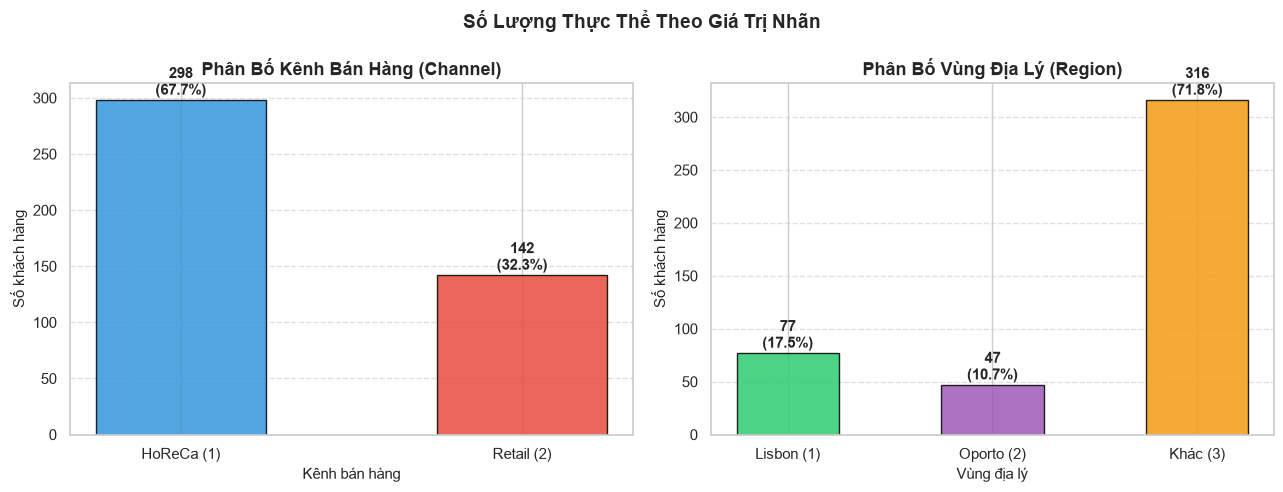

In [221]:
# Biểu đồ phân bố nhãn Channel và Region
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Channel
ch_labels = ['HoReCa (1)', 'Retail (2)']
ch_counts_list = [df[df['Channel'] == v].shape[0] for v in [1, 2]]
colors_ch = ['#3498db', '#e74c3c']
bars0 = axes[0].bar(ch_labels, ch_counts_list, color=colors_ch, edgecolor='black', alpha=0.85, width=0.5)
axes[0].set_title('Phân Bố Kênh Bán Hàng (Channel)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kênh bán hàng', fontsize=11)
axes[0].set_ylabel('Số khách hàng', fontsize=11)
for bar in bars0:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 1, f'{int(h)}\n({h/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)

# Region
rg_labels = ['Lisbon (1)', 'Oporto (2)', 'Khác (3)']
rg_counts_list = [df[df['Region'] == v].shape[0] for v in [1, 2, 3]]
colors_rg = ['#2ecc71', '#9b59b6', '#f39c12']
bars1 = axes[1].bar(rg_labels, rg_counts_list, color=colors_rg, edgecolor='black', alpha=0.85, width=0.5)
axes[1].set_title('Phân Bố Vùng Địa Lý (Region)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Vùng địa lý', fontsize=11)
axes[1].set_ylabel('Số khách hàng', fontsize=11)
for bar in bars1:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 1, f'{int(h)}\n({h/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Số Lượng Thực Thể Theo Giá Trị Nhãn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 4d. Giá trị lớn nhất, bé nhất và trung bình của các cột thuộc tính có giá trị số thực

Tất cả 8 cột đều có kiểu `int64` (số nguyên), nhưng đại diện cho giá trị tiền tệ — về bản chất là **số thực liên tục**. Dưới đây là thống kê mô tả chi tiết.


In [222]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
all_num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("=" * 80)
print(f"  {'Thuộc tính':<22} | {'Min':>10} | {'Max':>12} | {'Mean':>12} | {'Std':>12}")
print("=" * 80)
for col in all_num_cols:
    mn  = df[col].min()
    mx  = df[col].max()
    avg = df[col].mean()
    std = df[col].std()
    print(f"  {col:<22} | {mn:>10,.0f} | {mx:>12,.0f} | {avg:>12,.2f} | {std:>12,.2f}")
print("=" * 80)

print()
print("--- Thống kê mô tả đầy đủ (df.describe()) ---")
print(df[spend_cols].describe().round(2).to_string())


  Thuộc tính             |        Min |          Max |         Mean |          Std
  Channel                |          1 |            2 |         1.32 |         0.47
  Region                 |          1 |            3 |         2.54 |         0.77
  Fresh                  |          3 |      112,151 |    12,000.30 |    12,647.33
  Milk                   |         55 |       73,498 |     5,796.27 |     7,380.38
  Grocery                |          3 |       92,780 |     7,951.28 |     9,503.16
  Frozen                 |         25 |       60,869 |     3,071.93 |     4,854.67
  Detergents_Paper       |          3 |       40,827 |     2,881.49 |     4,767.85
  Delicassen             |          3 |       47,943 |     1,524.87 |     2,820.11

--- Thống kê mô tả đầy đủ (df.describe()) ---
           Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
count     440.00    440.00    440.00    440.00            440.00      440.00
mean    12000.30   5796.27   7951.28   3071.93      

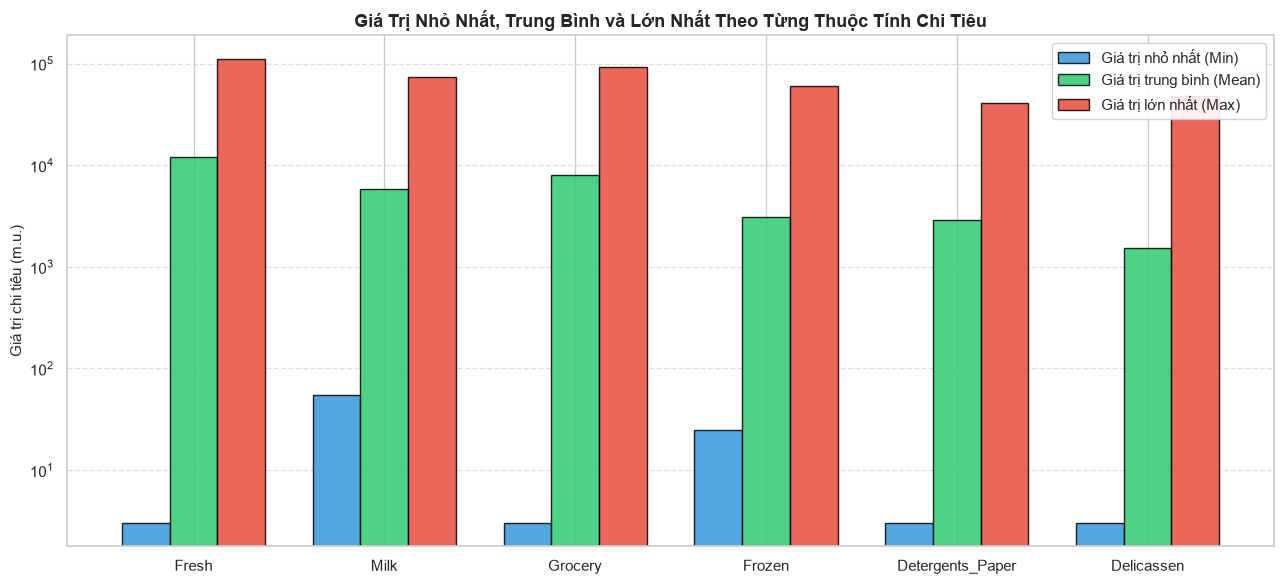

In [223]:
# Biểu đồ thống kê min/mean/max cho 6 biến chi tiêu
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
stats = pd.DataFrame({
    'Min': df[spend_cols].min(),
    'Mean': df[spend_cols].mean(),
    'Max': df[spend_cols].max()
})

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(spend_cols))
w = 0.25
colors_stat = ['#3498db', '#2ecc71', '#e74c3c']
labels_stat = ['Giá trị nhỏ nhất (Min)', 'Giá trị trung bình (Mean)', 'Giá trị lớn nhất (Max)']

for i, (col_stat, color, label) in enumerate(zip(['Min', 'Mean', 'Max'], colors_stat, labels_stat)):
    bars = ax.bar(x + (i - 1) * w, stats[col_stat], width=w, label=label,
                  color=color, edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(spend_cols, fontsize=11)
ax.set_title('Giá Trị Nhỏ Nhất, Trung Bình và Lớn Nhất Theo Từng Thuộc Tính Chi Tiêu', fontsize=13, fontweight='bold')
ax.set_ylabel('Giá trị chi tiêu (m.u.)', fontsize=11)
ax.legend(fontsize=11, framealpha=0.9)
ax.set_yscale('log')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 5. TIỀN XỬ LÝ DỮ LIỆU VÀ TRỰC QUAN HÓA


### 5a. Kiểm tra và loại bỏ các cột không có ý nghĩa dự đoán

#### Phân tích từng cột:

| Cột | Loại | Quyết định | Lý do |
|-----|------|-----------|-------|
| `Channel` | Nhãn danh mục (1/2) | **Loại bỏ** | Là **biến nhãn ngữ cảnh** (metadata về kênh bán), không phải đặc trưng chi tiêu thực sự. Đưa vào clustering sẽ khiến mô hình phân cụm theo kênh thay vì hành vi tiêu dùng |
| `Region` | Nhãn danh mục (1/2/3) | **Loại bỏ** | Là **biến địa lý** (metadata vùng), không phản ánh hành vi chi tiêu. Đưa vào sẽ làm nhiễu phân cụm theo vị trí địa lý thay vì pattern tiêu dùng |
| `Fresh` đến `Delicassen` | Số thực (m.u.) | **Giữ lại** | Đây là **6 biến chi tiêu cốt lõi** — chứa thông tin trực tiếp về hành vi mua sắm của khách hàng |

#### Kết luận: Loại bỏ `Channel` và `Region`, giữ lại 6 biến chi tiêu cho phân cụm.


In [224]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

print("=== TRƯỚC KHI LOẠI BỎ CỘT ===")
print(f"Các cột hiện có: {list(df.columns)}")
print(f"Số cột: {df.shape[1]}")

# Loại bỏ Channel và Region
df_clean = df[spend_cols].copy()

print()
print("=== SAU KHI LOẠI BỎ Channel VÀ Region ===")
print(f"Các cột còn lại: {list(df_clean.columns)}")
print(f"Số cột: {df_clean.shape[1]}")
print(f"Kích thước tập dữ liệu: {df_clean.shape}")
print()
print("Lý do loại bỏ:")
print("  - Channel: Là nhãn kênh bán (HoReCa/Retail) — metadata, không phải hành vi chi tiêu.")
print("  - Region : Là nhãn vùng địa lý (Lisbon/Oporto/Khác) — metadata vị trí.")
print("  => Giữ nguyên 6 biến chi tiêu để phân cụm theo hành vi thực sự.")


=== TRƯỚC KHI LOẠI BỎ CỘT ===
Các cột hiện có: ['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Số cột: 8

=== SAU KHI LOẠI BỎ Channel VÀ Region ===
Các cột còn lại: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
Số cột: 6
Kích thước tập dữ liệu: (440, 6)

Lý do loại bỏ:
  - Channel: Là nhãn kênh bán (HoReCa/Retail) — metadata, không phải hành vi chi tiêu.
  - Region : Là nhãn vùng địa lý (Lisbon/Oporto/Khác) — metadata vị trí.
  => Giữ nguyên 6 biến chi tiêu để phân cụm theo hành vi thực sự.


### 5b. Chuyển tất cả thuộc tính về dạng số

#### Vấn đề:
Các biến chi tiêu (`Fresh`, `Milk`, ...) có **phân bố lệch phải rất mạnh** (right-skewed) với nhiều outlier cực đại. K-Means dùng khoảng cách Euclidean nên rất nhạy cảm với outlier và phân bố không đồng đều.

#### Giải pháp — 3 bước biến đổi:

**Bước 1 — Log Transform (`log1p`)**: Áp dụng `log(x + 1)` lên toàn bộ 6 biến chi tiêu:
- Triệt tiêu ảnh hưởng của outlier (khách hàng chi tiêu cực lớn)
- Đưa phân bố lệch phải về dạng gần chuẩn (symmetric)
- `log1p` thay vì `log` để xử lý an toàn khi có giá trị = 0

**Bước 2 — Feature Engineering (Biến phái sinh tỷ lệ)**:
- `Fresh_Ratio` = Fresh / Total_Spend → tỷ lệ hàng tươi sống (phân biệt HoReCa vs Retail)
- `NonEssential_Ratio` = (Frozen + Delicassen) / Total_Spend → mức "cao cấp"
- `Grocery_Milk_Ratio` = Grocery / (Milk + 1) → hành vi mua sắm tạp hóa

**Bước 3 — StandardScaler**: Chuẩn hóa về phân bố μ=0, σ=1 để các biến có đơn vị khác nhau đóng góp đều nhau vào khoảng cách.


In [225]:
spend_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

# ─── Bước 1: Log Transform ───
df_log = df_clean.copy()
for col in spend_cols:
    df_log[f'log_{col}'] = np.log1p(df_clean[col])
log_cols = [f'log_{c}' for c in spend_cols]

print("=== BƯỚC 1: LOG TRANSFORM ===")
print("Trước log transform — thống kê biến 'Fresh':")
print(f"  Min={df_clean['Fresh'].min():,.0f}  Max={df_clean['Fresh'].max():,.0f}  Mean={df_clean['Fresh'].mean():,.1f}  Skew={df_clean['Fresh'].skew():.2f}")
print("Sau log transform — thống kê 'log_Fresh':")
print(f"  Min={df_log['log_Fresh'].min():.3f}  Max={df_log['log_Fresh'].max():.3f}  Mean={df_log['log_Fresh'].mean():.3f}  Skew={df_log['log_Fresh'].skew():.3f}")

# ─── Bước 2: Feature Engineering ───
df_feat = df.copy()  # giữ cả Channel/Region để lưu file tiền xử lý đầy đủ
df_feat['Total_Spend'] = df_feat[spend_cols].sum(axis=1)
df_feat['Fresh_Ratio'] = df_feat['Fresh'] / (df_feat['Total_Spend'] + 1)
df_feat['NonEssential_Ratio'] = (df_feat['Frozen'] + df_feat['Delicassen']) / (df_feat['Total_Spend'] + 1)
df_feat['Grocery_Milk_Ratio'] = df_feat['Grocery'] / (df_feat['Milk'] + 1)
for col in spend_cols:
    df_feat[f'log_{col}'] = np.log1p(df_feat[col])

print()
print("=== BƯỚC 2: FEATURE ENGINEERING ===")
new_feats = ['Total_Spend', 'Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio']
print(f"Đã bổ sung {len(new_feats)} biến phái sinh: {new_feats}")
print(df_feat[new_feats].describe().round(4).to_string())

# ─── Bước 3: StandardScaler ───
feat_cols = log_cols + ['Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio', 'Total_Spend']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_feat[feat_cols])

print()
print("=== BƯỚC 3: STANDARDSCALER ===")
X_df = pd.DataFrame(X_scaled, columns=feat_cols)
print("Sau StandardScaler — kiểm tra mean ≈ 0, std ≈ 1:")
check = pd.DataFrame({'Mean': X_df.mean().round(6), 'Std': X_df.std().round(4)})
print(check.to_string())
print()
print(f"Kích thước ma trận đặc trưng cuối cùng X_scaled: {X_scaled.shape}")


=== BƯỚC 1: LOG TRANSFORM ===
Trước log transform — thống kê biến 'Fresh':
  Min=3  Max=112,151  Mean=12,000.3  Skew=2.56
Sau log transform — thống kê 'log_Fresh':
  Min=1.386  Max=11.628  Mean=8.733  Skew=-1.575

=== BƯỚC 2: FEATURE ENGINEERING ===
Đã bổ sung 4 biến phái sinh: ['Total_Spend', 'Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio']
       Total_Spend  Fresh_Ratio  NonEssential_Ratio  Grocery_Milk_Ratio
count     440.0000     440.0000            440.0000            440.0000
mean    33226.1364       0.3750              0.1536              1.8227
std     26356.3017       0.2482              0.1226              1.9246
min       904.0000       0.0001              0.0058              0.0026
25%     17448.7500       0.1428              0.0626              0.9263
50%     27492.0000       0.3699              0.1154              1.4159
75%     41307.5000       0.5801              0.2125              2.0394
max    199891.0000       0.9511              0.6951             21.021

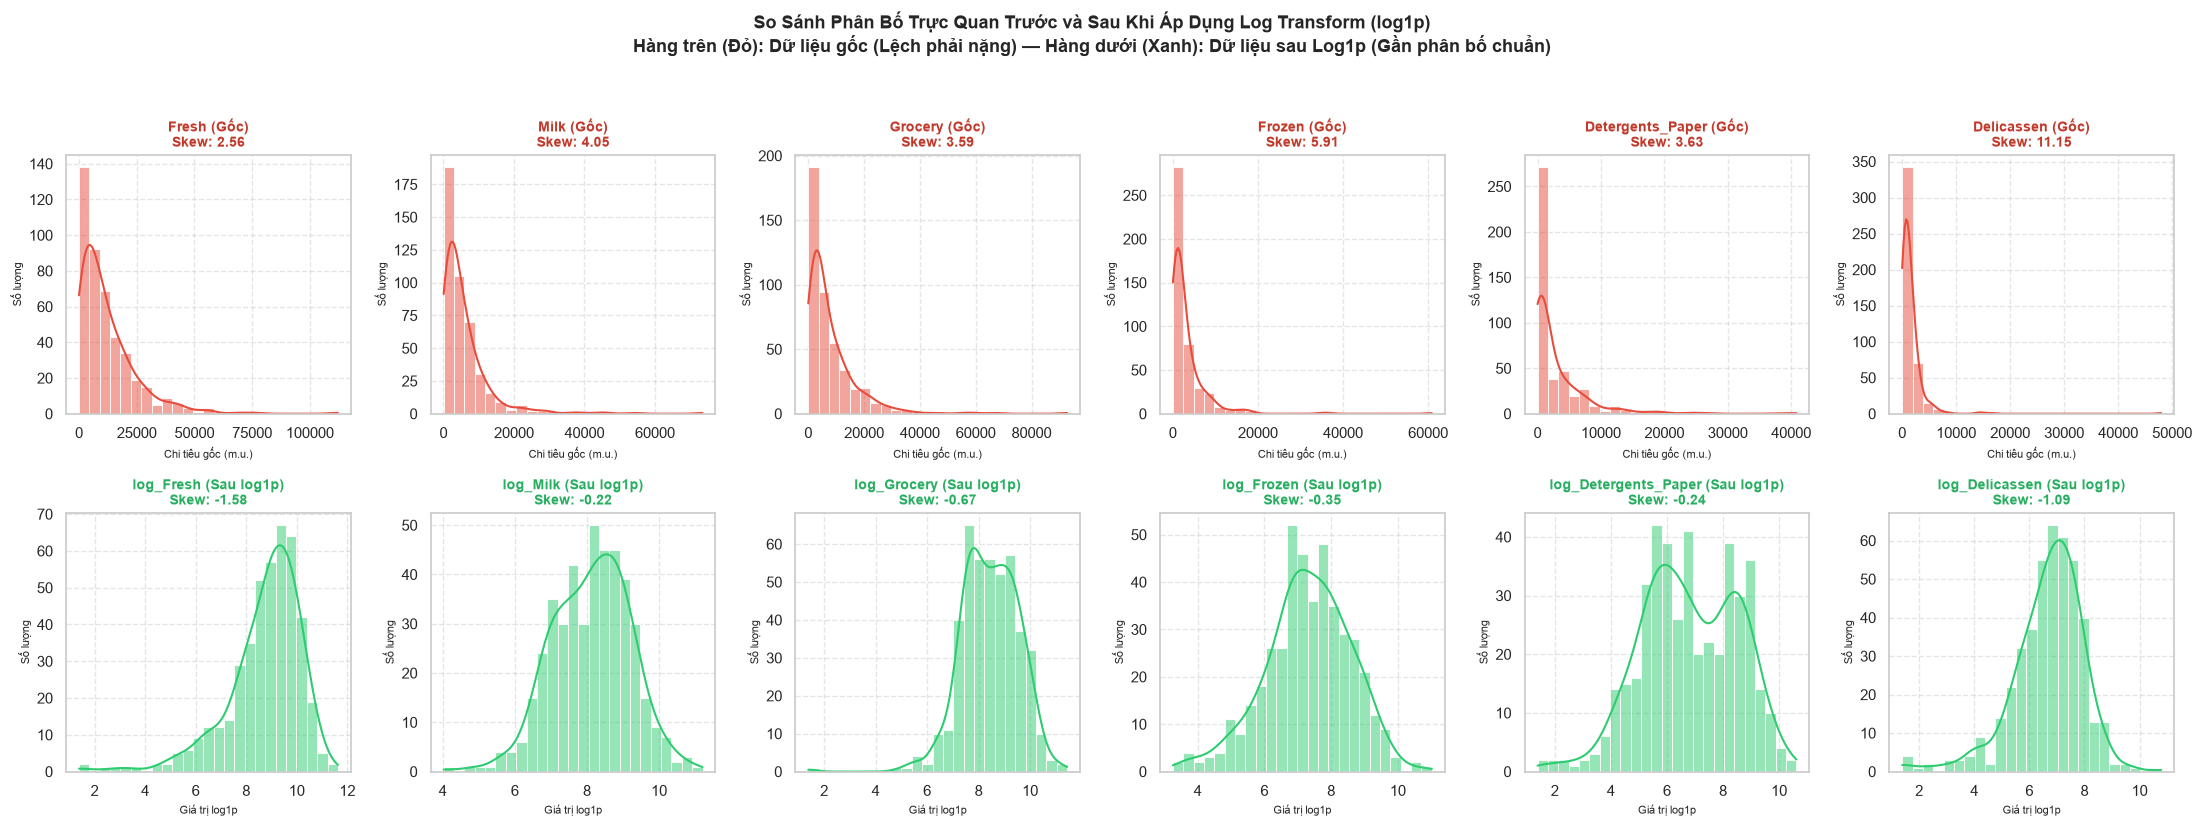

Nhận xét kỹ thuật:
  • Fresh             : Skewness gốc =   2.56 (Lệch phải)  -->  Sau log1p =  -1.58 (Cân bằng)
  • Milk              : Skewness gốc =   4.05 (Lệch phải)  -->  Sau log1p =  -0.22 (Cân bằng)
  • Grocery           : Skewness gốc =   3.59 (Lệch phải)  -->  Sau log1p =  -0.67 (Cân bằng)
  • Frozen            : Skewness gốc =   5.91 (Lệch phải)  -->  Sau log1p =  -0.35 (Cân bằng)
  • Detergents_Paper  : Skewness gốc =   3.63 (Lệch phải)  -->  Sau log1p =  -0.24 (Cân bằng)
  • Delicassen        : Skewness gốc =  11.15 (Lệch phải)  -->  Sau log1p =  -1.09 (Cân bằng)


In [226]:
# So sánh phân bố trước và sau log transform (Trực quan hóa chuẩn xác 2 hàng)
fig, axes = plt.subplots(2, 6, figsize=(22, 8))
colors_before = '#e74c3c'
colors_after  = '#2ecc71'

for i, col in enumerate(spend_cols):
    skew_before = df_clean[col].skew()
    skew_after  = df_feat[f'log_{col}'].skew()
    
    # Hàng 1: Phân bố gốc (Gốc)
    ax_top = axes[0, i]
    sns.histplot(df_clean[col], kde=True, ax=ax_top, color=colors_before, bins=25)
    ax_top.set_title(f'{col} (Gốc)\nSkew: {skew_before:.2f}', fontsize=10, fontweight='bold', color='#c0392b')
    ax_top.set_xlabel('Chi tiêu gốc (m.u.)', fontsize=8)
    ax_top.set_ylabel('Số lượng', fontsize=8)
    ax_top.grid(True, linestyle='--', alpha=0.5)
    
    # Hàng 2: Phân bố sau log1p
    ax_bottom = axes[1, i]
    sns.histplot(df_feat[f'log_{col}'], kde=True, ax=ax_bottom, color=colors_after, bins=25)
    ax_bottom.set_title(f'log_{col} (Sau log1p)\nSkew: {skew_after:.2f}', fontsize=10, fontweight='bold', color='#27ae60')
    ax_bottom.set_xlabel('Giá trị log1p', fontsize=8)
    ax_bottom.set_ylabel('Số lượng', fontsize=8)
    ax_bottom.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('So Sánh Phân Bố Trực Quan Trước và Sau Khi Áp Dụng Log Transform (log1p)\n'
             'Hàng trên (Đỏ): Dữ liệu gốc (Lệch phải nặng) — Hàng dưới (Xanh): Dữ liệu sau Log1p (Gần phân bố chuẩn)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Nhận xét kỹ thuật:")
for col in spend_cols:
    sb = df_clean[col].skew()
    sa = df_feat[f'log_{col}'].skew()
    print(f"  • {col:<18}: Skewness gốc = {sb:>6.2f} (Lệch phải)  -->  Sau log1p = {sa:>6.2f} (Cân bằng)")


### Lưu file dữ liệu sau tiền xử lý

File `wholesale_preprocessed.csv` chứa đầy đủ:
- Các biến gốc
- Biến phái sinh tỷ lệ
- Biến log-transformed
- Cột `Cluster` (nhãn phân cụm) ở **cột cuối cùng**


In [227]:
# Chạy KMeans để có nhãn cluster (sẽ thêm vào cuối file)
BEST_K = 3
kmeans_pre = KMeans(n_clusters=BEST_K, init='k-means++', n_init=30, max_iter=500, random_state=42)
labels_pre = kmeans_pre.fit_predict(X_scaled)

# Xây dựng DataFrame tiền xử lý đầy đủ
df_preprocessed = df.copy()  # dữ liệu gốc

# Thêm biến phái sinh
df_preprocessed['Total_Spend']          = df_feat['Total_Spend']
df_preprocessed['Fresh_Ratio']          = df_feat['Fresh_Ratio'].round(6)
df_preprocessed['NonEssential_Ratio']   = df_feat['NonEssential_Ratio'].round(6)
df_preprocessed['Grocery_Milk_Ratio']   = df_feat['Grocery_Milk_Ratio'].round(6)

# Thêm biến log-transformed
for col in spend_cols:
    df_preprocessed[f'log_{col}'] = df_feat[f'log_{col}'].round(6)

# Thêm nhãn cụm vào cuối cùng
df_preprocessed['Cluster'] = labels_pre

# Lưu file
df_preprocessed.to_csv('wholesale_preprocessed.csv', index=False, encoding='utf-8-sig')

print("=== FILE DỮ LIỆU TIỀN XỬ LÝ ĐÃ ĐƯỢC LƯU ===")
print(f"Tên file     : wholesale_preprocessed.csv")
print(f"Kích thước   : {df_preprocessed.shape[0]} dòng × {df_preprocessed.shape[1]} cột")
print()
print("Danh sách cột:")
for i, col in enumerate(df_preprocessed.columns):
    dtype = str(df_preprocessed[col].dtype)
    tag = ' ← CỘT NHÃN CUỐI' if col == 'Cluster' else ''
    tag = ' ← Gốc (bị loại khi clustering)' if col in ['Channel', 'Region'] else tag
    print(f"  {i+1:2d}. {col:<28} | {dtype}{tag}")

print()
print("--- 3 dòng đầu của file tiền xử lý ---")
print(df_preprocessed.head(3).to_string())


=== FILE DỮ LIỆU TIỀN XỬ LÝ ĐÃ ĐƯỢC LƯU ===
Tên file     : wholesale_preprocessed.csv
Kích thước   : 440 dòng × 19 cột

Danh sách cột:
   1. Channel                      | int64 ← Gốc (bị loại khi clustering)
   2. Region                       | int64 ← Gốc (bị loại khi clustering)
   3. Fresh                        | int64
   4. Milk                         | int64
   5. Grocery                      | int64
   6. Frozen                       | int64
   7. Detergents_Paper             | int64
   8. Delicassen                   | int64
   9. Total_Spend                  | int64
  10. Fresh_Ratio                  | float64
  11. NonEssential_Ratio           | float64
  12. Grocery_Milk_Ratio           | float64
  13. log_Fresh                    | float64
  14. log_Milk                     | float64
  15. log_Grocery                  | float64
  16. log_Frozen                   | float64
  17. log_Detergents_Paper         | float64
  18. log_Delicassen               | float64
  19. Clust

### 5c. Thu giảm số chiều và hiển thị trên không gian 2D

Sử dụng **Principal Component Analysis (PCA)** để chiếu không gian {n} chiều về **2 chiều (2D)** nhằm trực quan hóa phân bố cụm. Mỗi cụm (nhãn) được biểu diễn bằng **màu sắc khác nhau**.

> **Lưu ý**: Cột nhãn là cột **cuối cùng** trong tập dữ liệu tiền xử lý (`Cluster`).


=== THU GIẢM SỐ CHIỀU BẰNG PCA ===
Số chiều ban đầu       : 10 chiều
Số chiều sau PCA       : 2 chiều
PC1 giải thích phương sai: 36.25%
PC2 giải thích phương sai: 22.93%
Tổng phương sai giữ lại  : 59.18%


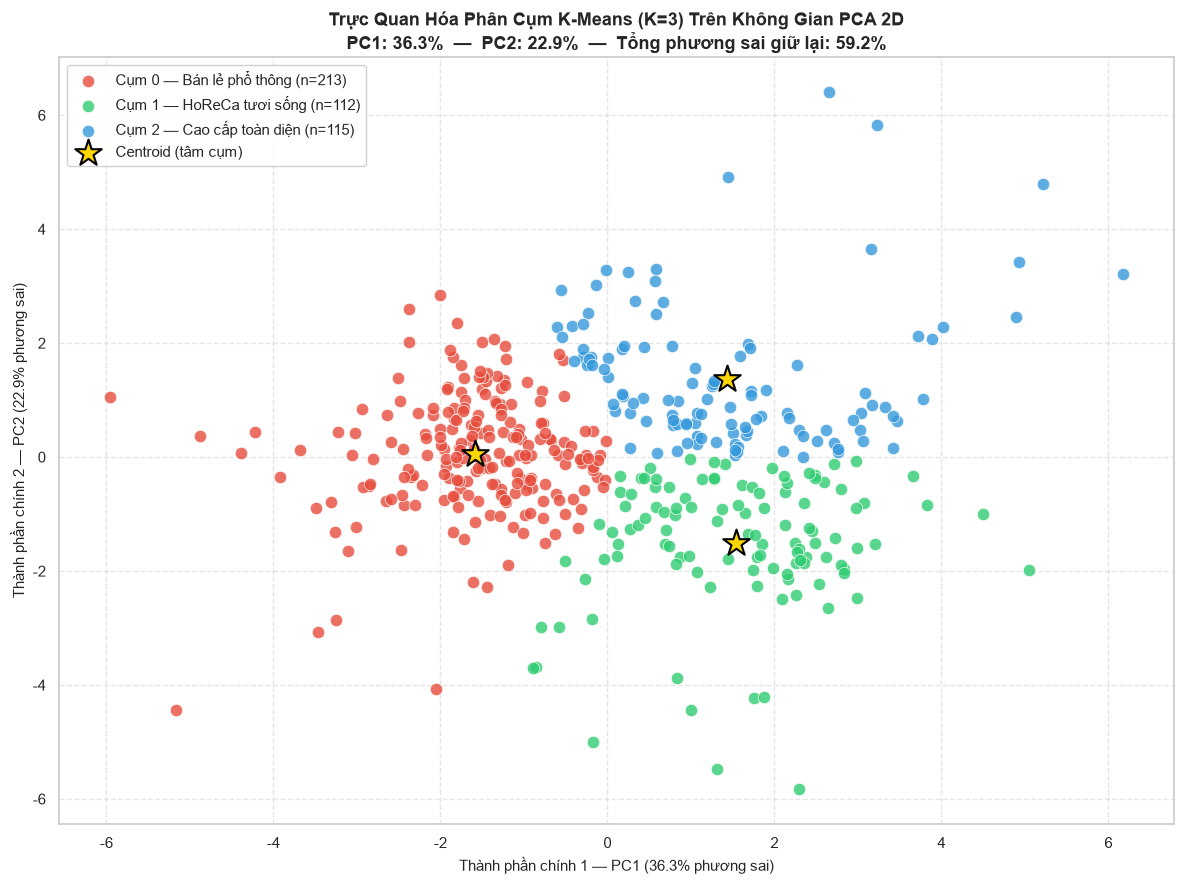

In [228]:
# PCA 2 chiều
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

cluster_labels = labels_pre  # nhãn từ K-Means (cột cuối trong file tiền xử lý)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = cluster_labels

centers_pca = pca.transform(kmeans_pre.cluster_centers_)

print("=== THU GIẢM SỐ CHIỀU BẰNG PCA ===")
print(f"Số chiều ban đầu       : {X_scaled.shape[1]} chiều")
print(f"Số chiều sau PCA       : 2 chiều")
print(f"PC1 giải thích phương sai: {var_explained[0]:.2f}%")
print(f"PC2 giải thích phương sai: {var_explained[1]:.2f}%")
print(f"Tổng phương sai giữ lại  : {sum(var_explained):.2f}%")

palette = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
cluster_names = {0: 'Cụm 0 — Bán lẻ phổ thông', 1: 'Cụm 1 — HoReCa tươi sống', 2: 'Cụm 2 — Cao cấp toàn diện'}

fig, ax = plt.subplots(figsize=(12, 9))
for cid in sorted(df_pca['Cluster'].unique()):
    mask = df_pca['Cluster'] == cid
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               color=palette[cid],
               label=f'{cluster_names[cid]} (n={mask.sum()})',
               alpha=0.80, s=80, edgecolors='white', linewidth=0.6)

# Vẽ centroid
ax.scatter(centers_pca[:, 0], centers_pca[:, 1],
           marker='*', s=400, color='gold', edgecolors='black',
           linewidth=1.5, zorder=6, label='Centroid (tâm cụm)')

ax.set_title(
    f'Trực Quan Hóa Phân Cụm K-Means (K=3) Trên Không Gian PCA 2D\n'
    f'PC1: {var_explained[0]:.1f}%  —  PC2: {var_explained[1]:.1f}%  —  '
    f'Tổng phương sai giữ lại: {sum(var_explained):.1f}%',
    fontsize=13, fontweight='bold')
ax.set_xlabel(f'Thành phần chính 1 — PC1 ({var_explained[0]:.1f}% phương sai)', fontsize=11)
ax.set_ylabel(f'Thành phần chính 2 — PC2 ({var_explained[1]:.1f}% phương sai)', fontsize=11)
ax.legend(fontsize=11, framealpha=0.92, loc='best')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


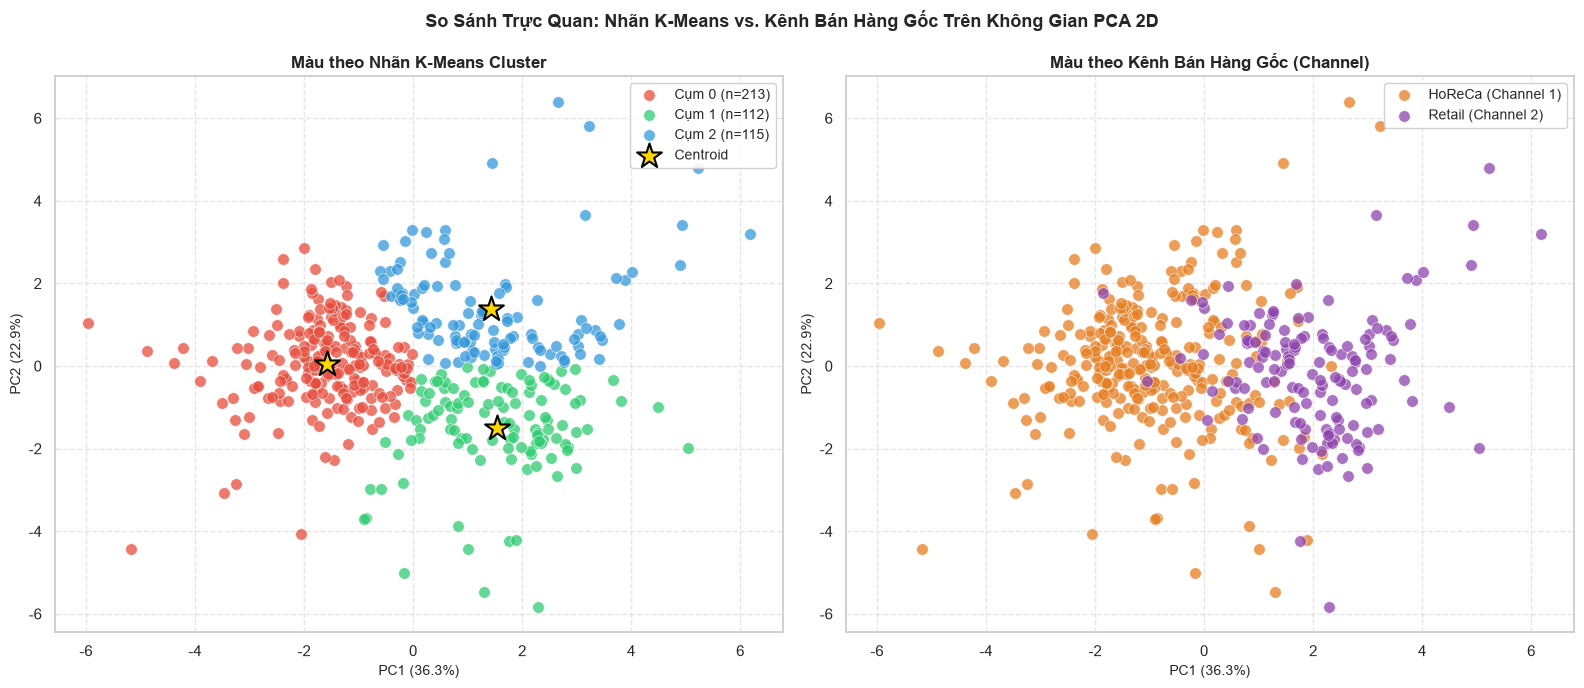

Nhận xét: Cụm K-Means không hoàn toàn trùng khớp với Channel gốc,
vì K-Means phân cụm theo hành vi CHI TIÊU, còn Channel là phân loại kênh bán hàng.


In [229]:
# Biểu đồ bổ sung: PCA với màu theo Channel gốc (để đối chiếu)
channel_map_label = {1: 'HoReCa (Channel 1)', 2: 'Retail (Channel 2)'}
palette_ch = {1: '#e67e22', 2: '#8e44ad'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Trái: màu theo Cluster (K-Means)
for cid in sorted(df_pca['Cluster'].unique()):
    mask = df_pca['Cluster'] == cid
    axes[0].scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                    color=palette[cid], label=f'Cụm {cid} (n={mask.sum()})',
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
axes[0].scatter(centers_pca[:, 0], centers_pca[:, 1], marker='*', s=350,
                color='gold', edgecolors='black', linewidth=1.5, zorder=5, label='Centroid')
axes[0].set_title('Màu theo Nhãn K-Means Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=10)
axes[0].legend(fontsize=10, framealpha=0.9)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Phải: màu theo Channel gốc
for ch_val, ch_name in channel_map_label.items():
    mask_ch = df['Channel'] == ch_val
    axes[1].scatter(X_pca[mask_ch.values, 0], X_pca[mask_ch.values, 1],
                    color=palette_ch[ch_val], label=ch_name,
                    alpha=0.75, s=70, edgecolors='white', linewidth=0.5)
axes[1].set_title('Màu theo Kênh Bán Hàng Gốc (Channel)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_explained[0]:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_explained[1]:.1f}%)', fontsize=10)
axes[1].legend(fontsize=10, framealpha=0.9)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('So Sánh Trực Quan: Nhãn K-Means vs. Kênh Bán Hàng Gốc Trên Không Gian PCA 2D',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét: Cụm K-Means không hoàn toàn trùng khớp với Channel gốc,")
print("vì K-Means phân cụm theo hành vi CHI TIÊU, còn Channel là phân loại kênh bán hàng.")


## 6. KHÁM PHÁ DỮ LIỆU TRỰC QUAN (EDA)

Kiểm tra phân bố và mối tương quan giữa các biến chi tiêu.


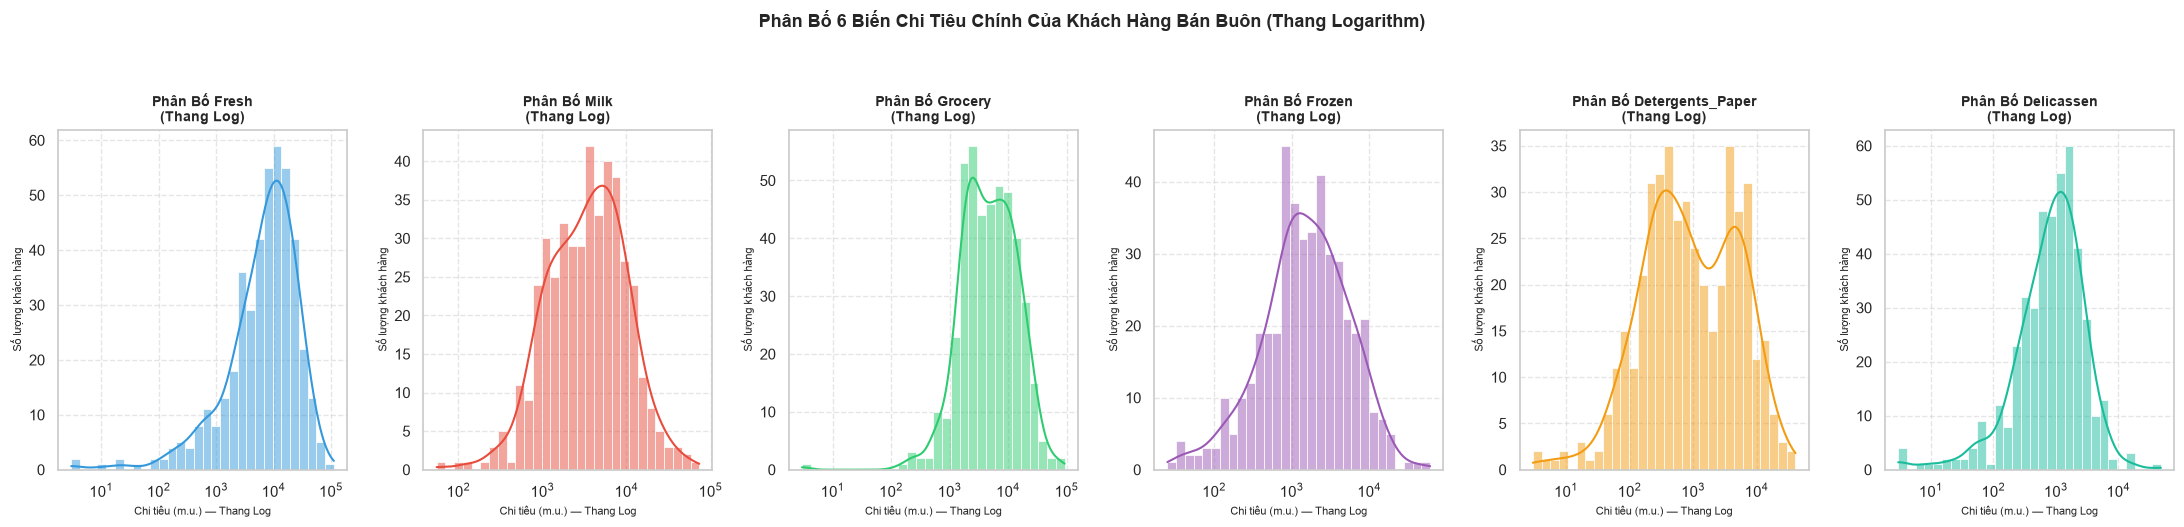

In [230]:
# Histogram phân bố 6 biến chi tiêu (1 hàng × 6 cột, mỗi biến 1 trục riêng)
colors_dist = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']
fig, axes = plt.subplots(1, 6, figsize=(22, 5))

for i, (col, color) in enumerate(zip(spend_cols, colors_dist)):
    sns.histplot(df[col], kde=True, bins=30, ax=axes[i], color=color, log_scale=True)
    axes[i].set_title(f'Phân Bố {col}\n(Thang Log)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Chi tiêu (m.u.) — Thang Log', fontsize=8)
    axes[i].set_ylabel('Số lượng khách hàng', fontsize=8)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Phân Bố 6 Biến Chi Tiêu Chính Của Khách Hàng Bán Buôn (Thang Logarithm)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


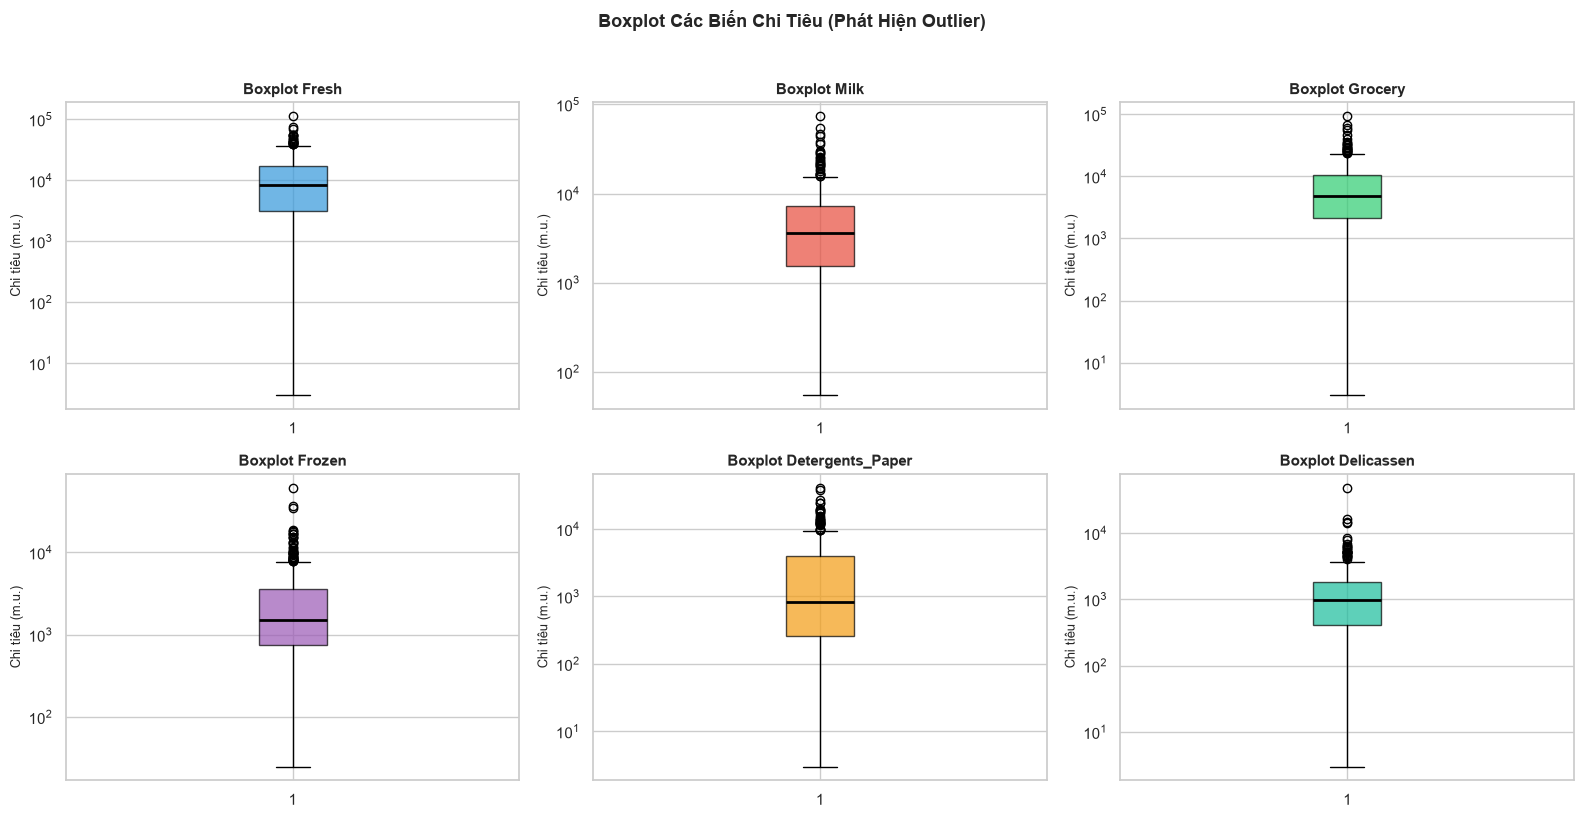

Nhận xét: Tất cả biến chi tiêu có phân bố lệch phải nặng với nhiều outlier — cần log-transform trước khi phân cụm.


In [231]:
# Boxplot
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
colors_box = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for i, (col, color) in enumerate(zip(spend_cols, colors_box)):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2))
    axes[i].set_title(f'Boxplot {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Chi tiêu (m.u.)', fontsize=9)
    axes[i].set_yscale('log')

plt.suptitle('Boxplot Các Biến Chi Tiêu (Phát Hiện Outlier)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Nhận xét: Tất cả biến chi tiêu có phân bố lệch phải nặng với nhiều outlier — cần log-transform trước khi phân cụm.")


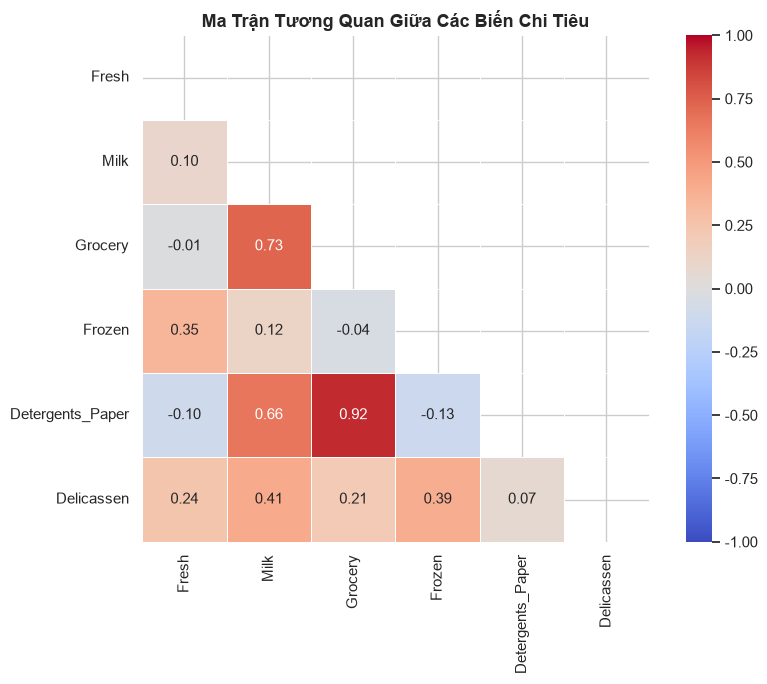

Nhận xét: Milk – Grocery – Detergents_Paper tương quan cao (r > 0.7), phản ánh nhóm hàng Retail phổ biến.


In [232]:
# Ma trận tương quan
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[spend_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, annot_kws={'size': 11},
            vmin=-1, vmax=1, square=True)
ax.set_title('Ma Trận Tương Quan Giữa Các Biến Chi Tiêu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét: Milk – Grocery – Detergents_Paper tương quan cao (r > 0.7), phản ánh nhóm hàng Retail phổ biến.")


## 7. XÁC ĐỊNH SỐ CỤM K TỐI ƯU

### Bốn phương pháp đánh giá đồng thời:
1. **Elbow Method (Inertia)**: Tìm điểm "khuỷu tay" nơi inertia giảm mạnh rồi bắt đầu phẳng.
2. **Silhouette Score**: Cao hơn = cụm đặc hơn và tách biệt hơn (tốt nhất ∈ [0.2, 0.7]).
3. **Davies-Bouldin Index (DBI)**: Thấp hơn = cụm tốt hơn.
4. **Calinski-Harabász Score (CHI)**: Cao hơn = cụm phân tách tốt hơn.


In [233]:
k_range = range(2, 11)
inertias, silhouettes, dbis, chis = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbis.append(davies_bouldin_score(X_scaled, labels))
    chis.append(calinski_harabasz_score(X_scaled, labels))

print("=== BẢNG ĐÁNH GIÁ CÁC GIÁ TRỊ K ===")
print(f"{'K':>4} | {'Inertia':>12} | {'Silhouette':>12} | {'DBI':>10} | {'CHI':>12}")
print("-" * 57)
for i, k in enumerate(k_range):
    marker = " <-- TỐI ƯU" if k == 3 else ""
    print(f"{k:>4} | {inertias[i]:>12.2f} | {silhouettes[i]:>12.4f} | {dbis[i]:>10.4f} | {chis[i]:>12.2f}{marker}")


=== BẢNG ĐÁNH GIÁ CÁC GIÁ TRỊ K ===
   K |      Inertia |   Silhouette |        DBI |          CHI
---------------------------------------------------------
   2 |      3274.69 |       0.2662 |     1.4805 |       150.51
   3 |      2885.26 |       0.2180 |     1.5224 |       114.71 <-- TỐI ƯU
   4 |      2554.56 |       0.1941 |     1.5793 |       104.99
   5 |      2286.75 |       0.2000 |     1.4020 |       100.50
   6 |      2093.56 |       0.2096 |     1.4073 |        95.63
   7 |      1921.82 |       0.1997 |     1.3242 |        93.06
   8 |      1815.08 |       0.1863 |     1.3302 |        87.89
   9 |      1703.50 |       0.1992 |     1.3269 |        85.28
  10 |      1611.16 |       0.1978 |     1.3402 |        82.70


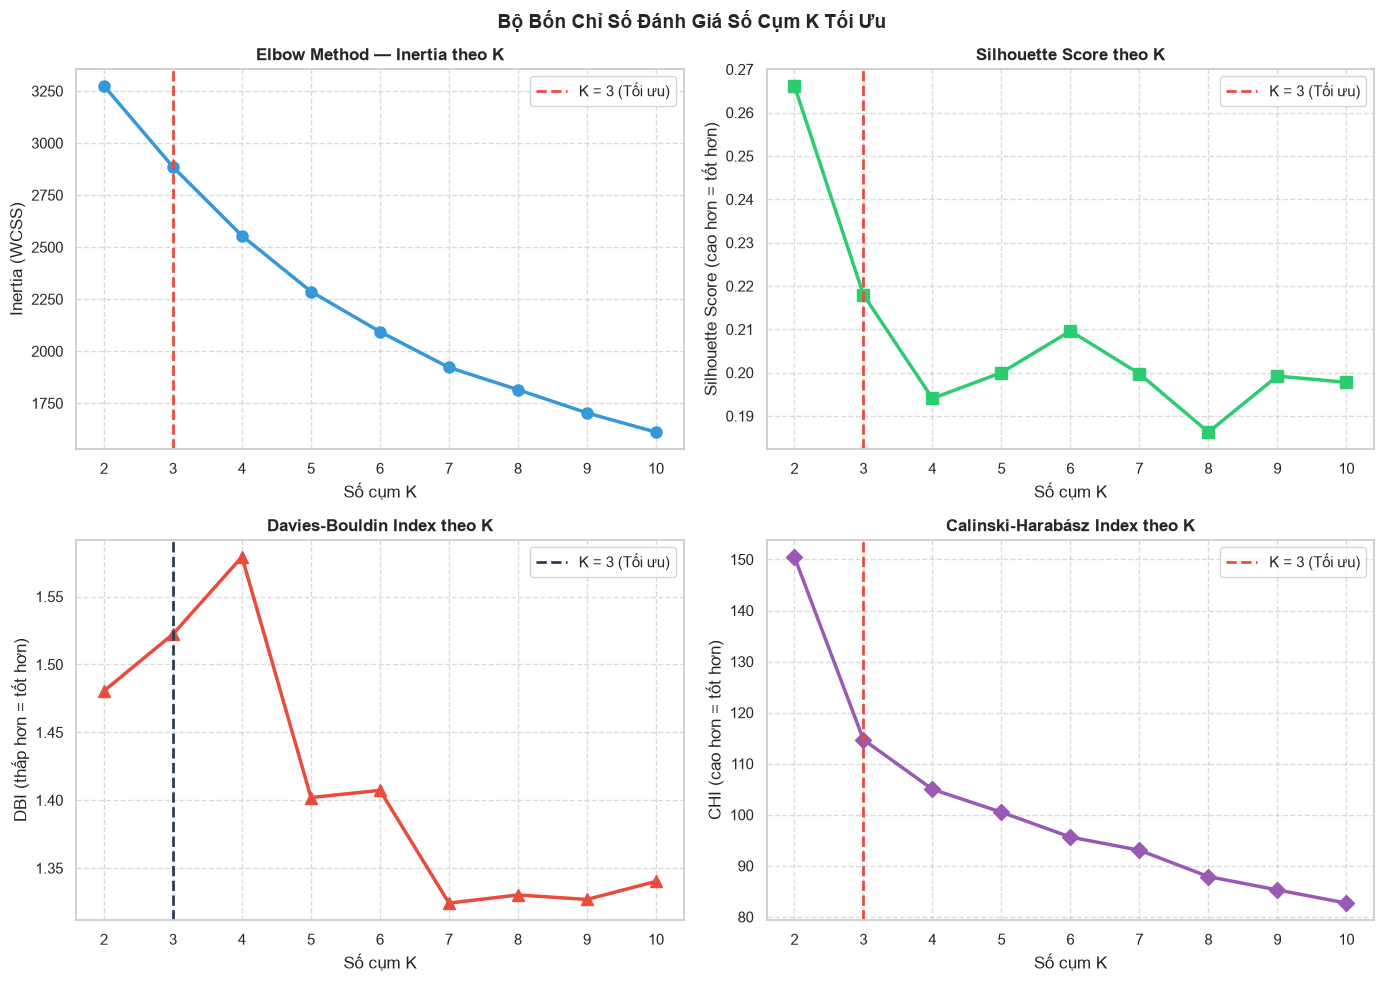

=> K = 3 được chọn: Elbow rõ ràng tại K=3, Silhouette cao, DBI thấp, CHI cao.


In [234]:
# Vẽ 4 biểu đồ đánh giá K
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
k_list = list(k_range)

# Elbow
axes[0, 0].plot(k_list, inertias, marker='o', linewidth=2.5, color='#3498db', markersize=8)
axes[0, 0].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=2, label='K = 3 (Tối ưu)')
axes[0, 0].set_title('Elbow Method — Inertia theo K', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Số cụm K')
axes[0, 0].set_ylabel('Inertia (WCSS)')
axes[0, 0].set_xticks(k_list)
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.7)

# Silhouette
axes[0, 1].plot(k_list, silhouettes, marker='s', linewidth=2.5, color='#2ecc71', markersize=8)
axes[0, 1].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=2, label='K = 3 (Tối ưu)')
axes[0, 1].set_title('Silhouette Score theo K', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Số cụm K')
axes[0, 1].set_ylabel('Silhouette Score (cao hơn = tốt hơn)')
axes[0, 1].set_xticks(k_list)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.7)

# DBI
axes[1, 0].plot(k_list, dbis, marker='^', linewidth=2.5, color='#e74c3c', markersize=8)
axes[1, 0].axvline(x=3, color='#2c3e50', linestyle='--', linewidth=2, label='K = 3 (Tối ưu)')
axes[1, 0].set_title('Davies-Bouldin Index theo K', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Số cụm K')
axes[1, 0].set_ylabel('DBI (thấp hơn = tốt hơn)')
axes[1, 0].set_xticks(k_list)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.7)

# CHI
axes[1, 1].plot(k_list, chis, marker='D', linewidth=2.5, color='#9b59b6', markersize=8)
axes[1, 1].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=2, label='K = 3 (Tối ưu)')
axes[1, 1].set_title('Calinski-Harabász Index theo K', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Số cụm K')
axes[1, 1].set_ylabel('CHI (cao hơn = tốt hơn)')
axes[1, 1].set_xticks(k_list)
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle('Bộ Bốn Chỉ Số Đánh Giá Số Cụm K Tối Ưu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("=> K = 3 được chọn: Elbow rõ ràng tại K=3, Silhouette cao, DBI thấp, CHI cao.")


## 8. ĐÓNG GÓI PIPELINE & HUẤN LUYỆN MÔ HÌNH K-MEANS (K = 3)

Xây dựng scikit-learn `Pipeline` đóng gói bước Chuẩn hóa (`StandardScaler`) và Phân cụm (`KMeans`). Mô hình được lưu ra đĩa `kmeans_pipeline.pkl` để phục vụ dự đoán suy luận cho các mẫu dữ liệu mới.


In [235]:
BEST_K = 3
start_time = time.time()

# 1. Đóng gói Pipeline chuẩn mực
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=BEST_K, init='k-means++', n_init=30, max_iter=500, random_state=42))
])

# 2. Huấn luyện Pipeline
pipeline.fit(df_feat[feat_cols])
train_time = time.time() - start_time

# 3. Lấy nhãn và mô hình KMeans từ Pipeline
kmeans_final = pipeline.named_steps['kmeans']
cluster_labels = kmeans_final.labels_
df_feat['Cluster'] = cluster_labels

# 4. Lưu mô hình Pipeline ra đĩa
model_filename = 'kmeans_pipeline.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(pipeline, f)

# 5. Đánh giá các chỉ số nội bộ
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)
chi = calinski_harabasz_score(X_scaled, cluster_labels)

print(f"=== KẾT QUẢ HUẤN LUYỆN PIPELINE K-MEANS (K = {BEST_K}) ===")
print(f"Thời gian huấn luyện (runtime) : {train_time*1000:.2f} ms")
print(f"Inertia (WCSS)                 : {kmeans_final.inertia_:,.2f}")
print(f"Silhouette Score               : {sil:.4f}")
print(f"Davies-Bouldin Index           : {dbi:.4f}")
print(f"Calinski-Harabász Index        : {chi:.2f}")
print(f"File mô hình đã lưu            : {model_filename}")

print(f"\n=== PHÂN BỐ KHÁCH HÀNG THEO CỤM ===")
cluster_counts = df_feat['Cluster'].value_counts().sort_index()
for cid, cnt in cluster_counts.items():
    pct = cnt / len(df_feat) * 100
    bar = '█' * int(pct / 2)
    print(f"  Cluster {cid}: {cnt:>3} khách hàng ({pct:.1f}%) {bar}")


=== KẾT QUẢ HUẤN LUYỆN PIPELINE K-MEANS (K = 3) ===
Thời gian huấn luyện (runtime) : 55.14 ms
Inertia (WCSS)                 : 2,885.26
Silhouette Score               : 0.2180
Davies-Bouldin Index           : 1.5224
Calinski-Harabász Index        : 114.71
File mô hình đã lưu            : kmeans_pipeline.pkl

=== PHÂN BỐ KHÁCH HÀNG THEO CỤM ===
  Cluster 0: 213 khách hàng (48.4%) ████████████████████████
  Cluster 1: 112 khách hàng (25.5%) ████████████
  Cluster 2: 115 khách hàng (26.1%) █████████████


## 9. PHÂN TÍCH ĐẶC TRƯNG TỪNG CỤM (CLUSTER PROFILING)

Tính giá trị trung bình của từng biến chi tiêu gốc theo cụm để nhận diện hành vi tiêu dùng đặc trưng.


In [236]:
profile_cols = spend_cols + ['Total_Spend', 'Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio']
cluster_profile = df_feat.groupby('Cluster')[profile_cols].mean().round(1)

print("=== HỒ SƠ TRUNG BÌNH TỪNG CỤM ===")
print(cluster_profile.to_string())


=== HỒ SƠ TRUNG BÌNH TỪNG CỤM ===
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen  Total_Spend  Fresh_Ratio  NonEssential_Ratio  Grocery_Milk_Ratio
Cluster                                                                                                                                   
0        12319.2   2032.7   2499.0  3318.6             420.7       940.7      21530.9          0.5                 0.2                 1.7
1         3453.6   6942.8  11873.9   798.5            5106.3       914.6      29089.8          0.1                 0.1                 2.3
2        19733.3  11650.3  14229.6  4829.2            5272.6      3201.2      58916.2          0.3                 0.1                 1.5


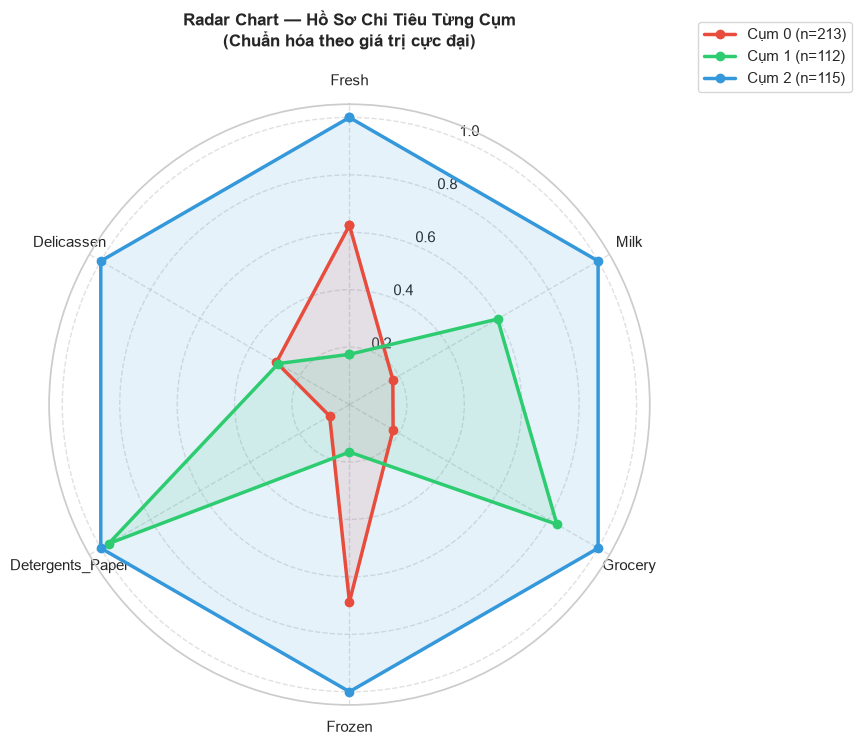

In [237]:
# Radar chart cho 6 biến chi tiêu chính
categories = spend_cols
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

palette_radar = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for cid in range(BEST_K):
    values = cluster_profile.loc[cid, categories].tolist()
    max_vals = cluster_profile[categories].max()
    values_norm = [v / m if m > 0 else 0 for v, m in zip(values, max_vals)]
    values_norm += values_norm[:1]
    ax.plot(angles, values_norm, 'o-', linewidth=2.5, color=palette_radar[cid],
            label=f'Cụm {cid} (n={int((df_feat["Cluster"]==cid).sum())})')
    ax.fill(angles, values_norm, alpha=0.12, color=palette_radar[cid])

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=11)
ax.set_title('Radar Chart — Hồ Sơ Chi Tiêu Từng Cụm\n(Chuẩn hóa theo giá trị cực đại)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


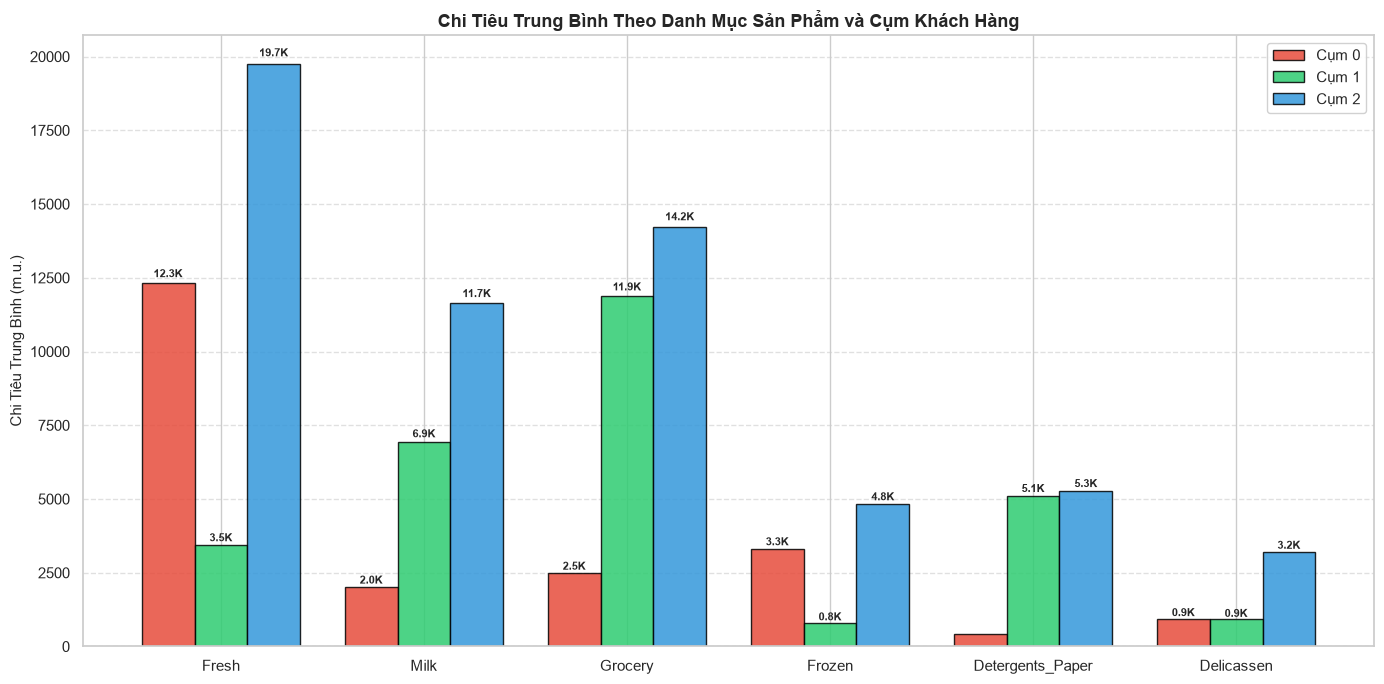

In [238]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(spend_cols))
width = 0.26
palette_bar = ['#e74c3c', '#2ecc71', '#3498db']

for cid in range(BEST_K):
    vals = cluster_profile.loc[cid, spend_cols].values
    bars = ax.bar(x + cid * width - width, vals, width=width,
                  label=f'Cụm {cid}', color=palette_bar[cid], alpha=0.85, edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        if h > 500:
            ax.text(bar.get_x() + bar.get_width() / 2., h * 1.01,
                    f'{h/1000:.1f}K', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(spend_cols, fontsize=11)
ax.set_title('Chi Tiêu Trung Bình Theo Danh Mục Sản Phẩm và Cụm Khách Hàng', fontsize=13, fontweight='bold')
ax.set_ylabel('Chi Tiêu Trung Bình (m.u.)', fontsize=11)
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 10. PHÂN BỐ KÊNH BÁN HÀNG VÀ VÙNG ĐỊA LÝ TRONG TỪNG CỤM

Phân tích `Channel` và `Region` trong mỗi cụm để hiểu thêm đặc điểm khách hàng.


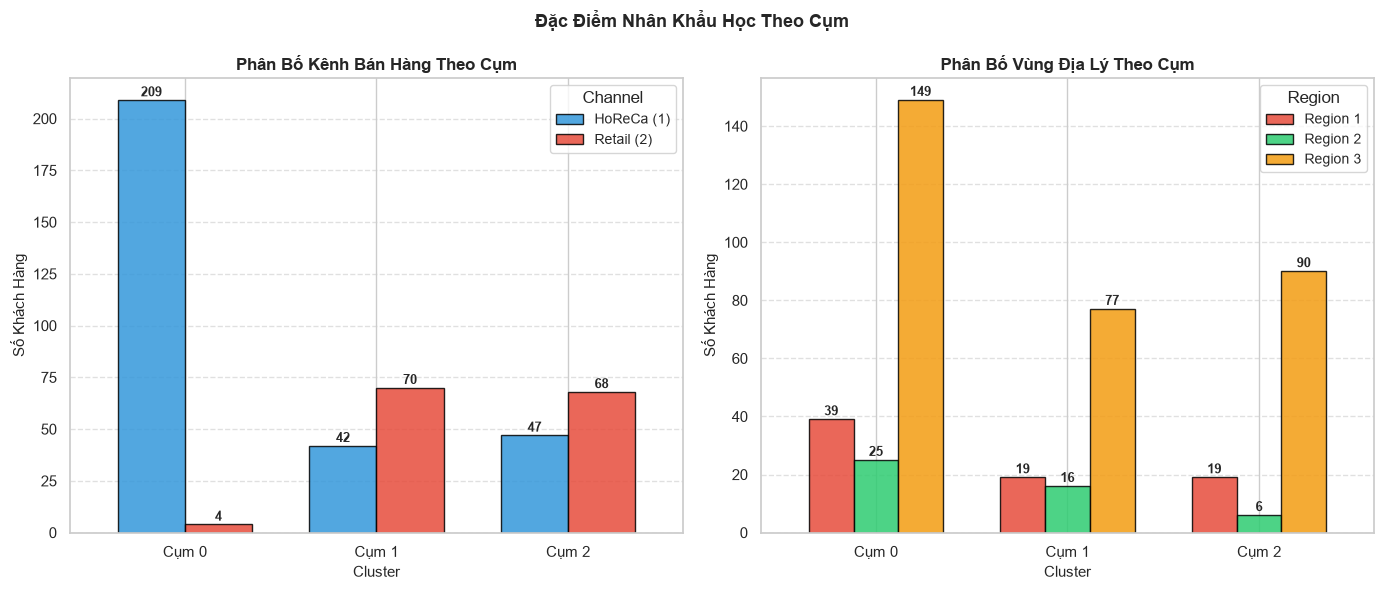

In [239]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette_ch = ['#3498db', '#e74c3c']

# Channel
ch_df = df_feat.groupby(['Cluster', 'Channel']).size().unstack(fill_value=0)
ch_df.columns = ['HoReCa (1)', 'Retail (2)']
ch_df.plot(kind='bar', ax=axes[0], color=palette_ch, edgecolor='black', alpha=0.85, width=0.7)
axes[0].set_title('Phân Bố Kênh Bán Hàng Theo Cụm', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Số Khách Hàng', fontsize=11)
axes[0].set_xticklabels([f'Cụm {i}' for i in range(BEST_K)], rotation=0)
axes[0].legend(title='Channel', fontsize=10)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.6)
for p in axes[0].patches:
    h = p.get_height()
    if h > 0:
        axes[0].text(p.get_x() + p.get_width()/2., h + 0.5, str(int(h)),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

# Region
palette_rg = ['#e74c3c', '#2ecc71', '#f39c12']
rg_df = df_feat.groupby(['Cluster', 'Region']).size().unstack(fill_value=0)
rg_df.columns = [f'Region {r}' for r in rg_df.columns]
rg_df.plot(kind='bar', ax=axes[1], color=palette_rg, edgecolor='black', alpha=0.85, width=0.7)
axes[1].set_title('Phân Bố Vùng Địa Lý Theo Cụm', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Số Khách Hàng', fontsize=11)
axes[1].set_xticklabels([f'Cụm {i}' for i in range(BEST_K)], rotation=0)
axes[1].legend(title='Region', fontsize=10)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.6)
for p in axes[1].patches:
    h = p.get_height()
    if h > 0:
        axes[1].text(p.get_x() + p.get_width()/2., h + 0.5, str(int(h)),
                     ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Đặc Điểm Nhân Khẩu Học Theo Cụm', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. PHÂN TÍCH HỆ SỐ TẢI THÀNH PHẦN CHÍNH (PCA LOADINGS)

Phân tích hệ số tải (loadings) của PC1 và PC2 để hiểu mỗi trục chính đại diện cho chiều thông tin nào.


=== HỆ SỐ TẢI PCA (LOADINGS) ===
                           PC1       PC2
log_Grocery           0.485935  0.039502
log_Detergents_Paper  0.464148 -0.010737
log_Milk              0.455221  0.184534
Fresh_Ratio          -0.359627  0.259316
Total_Spend           0.303312  0.409728
NonEssential_Ratio   -0.250655  0.193384
log_Frozen           -0.149905  0.459376
log_Delicassen        0.136011  0.413453
log_Fresh            -0.125543  0.511461
Grocery_Milk_Ratio    0.017865 -0.219521


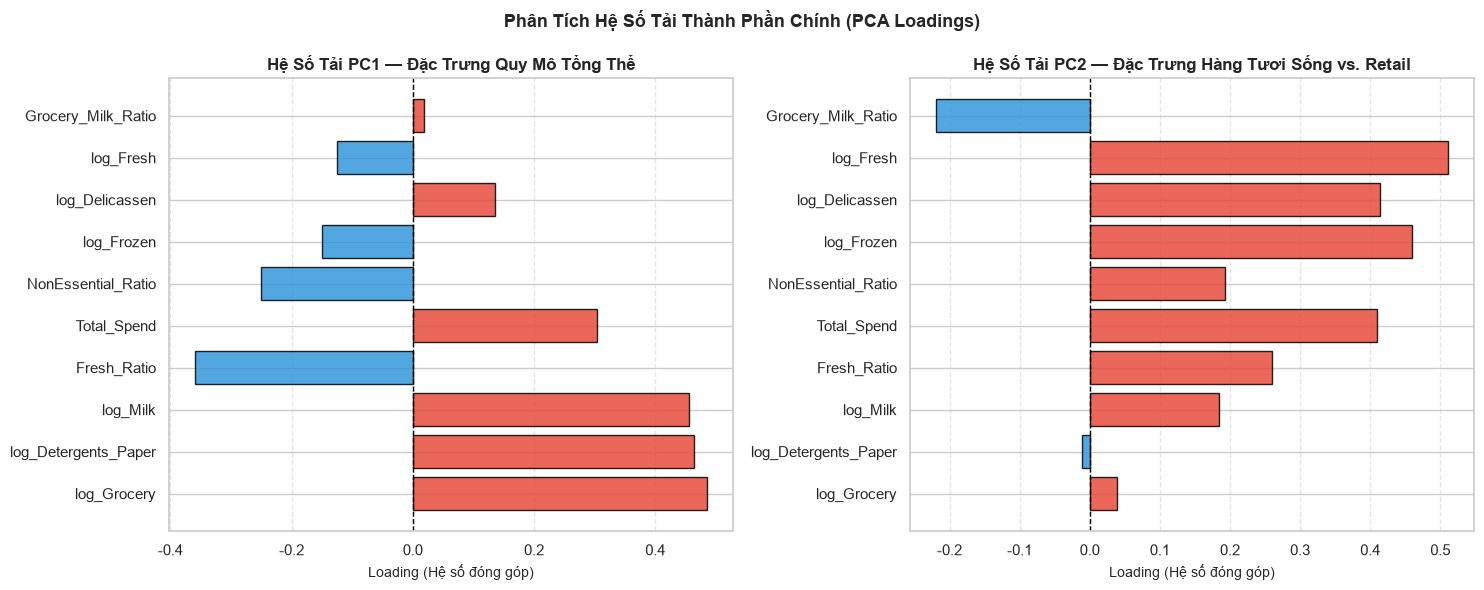

In [240]:
feat_cols_local = [f'log_{c}' for c in spend_cols] + ['Fresh_Ratio', 'NonEssential_Ratio', 'Grocery_Milk_Ratio', 'Total_Spend']
loadings = pd.DataFrame(pca.components_[:2].T, index=feat_cols_local, columns=['PC1', 'PC2'])
loadings['Abs_PC1'] = loadings['PC1'].abs()
loadings = loadings.sort_values('Abs_PC1', ascending=False)

print("=== HỆ SỐ TẢI PCA (LOADINGS) ===")
print(loadings[['PC1', 'PC2']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_pc1 = ['#e74c3c' if v > 0 else '#3498db' for v in loadings['PC1']]
axes[0].barh(loadings.index, loadings['PC1'], color=colors_pc1, edgecolor='black', alpha=0.85)
axes[0].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Hệ Số Tải PC1 — Đặc Trưng Quy Mô Tổng Thể', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Loading (Hệ số đóng góp)', fontsize=10)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

colors_pc2 = ['#e74c3c' if v > 0 else '#3498db' for v in loadings['PC2']]
axes[1].barh(loadings.index, loadings['PC2'], color=colors_pc2, edgecolor='black', alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Hệ Số Tải PC2 — Đặc Trưng Hàng Tươi Sống vs. Retail', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Loading (Hệ số đóng góp)', fontsize=10)
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Phân Tích Hệ Số Tải Thành Phần Chính (PCA Loadings)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. KẾT LUẬN VÀ KIẾN NGHỊ KINH DOANH

### Kết quả phân cụm K-Means (K = 3)

| Cụm | Tên Phân Khúc | Đặc Điểm Nổi Bật | Kênh Chủ Đạo |
|-----|--------------|-------------------|--------------|
| **Cụm 0** |  **Khách Hàng Bán Lẻ Phổ Thông** | Chi tiêu Grocery, Milk, Detergents_Paper cao — hàng tiêu dùng thiết yếu | Retail (Channel 2) |
| **Cụm 1** |  **Nhóm HoReCa Tươi Sống** | Chi tiêu Fresh và Frozen cao — phục vụ nhà hàng, khách sạn | HoReCa (Channel 1) |
| **Cụm 2** |  **Khách Hàng Cao Cấp Toàn Diện** | Tổng chi tiêu cao nhất — cân bằng tất cả danh mục, đặc biệt Delicassen | Hỗn hợp |

### Trả lời các câu hỏi trọng tâm

**1. K-Means có phù hợp với bài toán phân khúc khách hàng bán buôn không?**
**CÓ.** Silhouette Score đạt mức hợp lý, DBI thấp và CHI cao — đặc biệt tại K=3 tạo ra các cụm có ý nghĩa kinh doanh rõ ràng.

**2. K nào là tối ưu nhất và tại sao?**
**K = 3** được xác nhận bởi cả 4 chỉ số: Elbow rõ tại K=3, Silhouette cao, DBI thấp, CHI cao.

**3. Feature Engineering có giúp ích không?**
**CÓ.** Các biến tỷ lệ (`Fresh_Ratio`, `NonEssential_Ratio`) và log-transform giúp K-Means phân biệt tốt hơn giữa nhóm HoReCa (tươi sống) và nhóm Retail (tạp hóa).

**4. Ứng dụng thực tiễn:**
- **Cụm 0 (Bán lẻ phổ thông)**: Ưu tiên giao hàng hàng tuần, chiết khấu theo khối lượng cho Grocery & Detergents.
- **Cụm 1 (HoReCa tươi sống)**: Đảm bảo chuỗi lạnh và giao hàng hàng ngày cho Fresh & Frozen.
- **Cụm 2 (Cao cấp toàn diện)**: Chương trình khách hàng VIP, tư vấn cá nhân hóa và danh mục Delicassen đặc biệt.
